# Evaluation

In [1]:
import itertools
import json
import pathlib

import itables
import matplotlib.pyplot as plt
import numpy
import pandas

In [2]:
INPUT_DIRS = ['machines']
INPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.txt'), INPUT_DIRS)))

## Info

In [3]:
import evaluate
MACHINES = evaluate._um_read_stats_as_dataframe(INPUT)
itables.show(MACHINES)

Loading ITables v2.8.0 from the internet... (need help?)


## Runs

In [4]:
# last updated: 2026-06-05
PRICING = {
    # https://api-docs.deepseek.com/quick_start/pricing/
    'deepseek': {
        'deepseek-v4-pro':   (.435/1e6, .87/1e6), 
        'deepseek-v4-flash': (.14/1e6,  .28/1e6), 
    },
    # https://ai.google.dev/gemini-api/docs/pricing
    'google-genai': {
        'gemini-2.5-pro': (2.5/1e6, 15./1e6),
    },
    # https://developers.openai.com/api/docs/models/gpt-5.4
    'openai': {
        'gpt-5.5':      (5.0/1e6,  30./1e6),
        'gpt-5.4':      (2.5/1e6,  15./1e6), 
        'gpt-5.2':      (1.75/1e6, 14./1e6),
        'gpt-5.4-mini': (.75/1e6,  4.5/1e6),
        'gpt-5.4-nano': (.20/1e6,  1.25/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.

In [5]:
def load(runs):
    for path in runs:
        with open(path, 'rt', encoding='utf-8') as fp:
            t = json.load(fp)
            yield {
                'D': t['digest'],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                'provider': t['provider'],
                'model': t['model'],
                #'prompt': t['prompt'],
                #'temperature': t['temperature'],
                #'seed': t['seed'],
                #'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'progress': t['cycles'] / t['cycles_until_halt'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                'input_tokens': t['usage_metadata']['input_tokens'],
                'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }

In [6]:
OUTPUT_DIRS = ['runs']
OUTPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.json'), OUTPUT_DIRS)))
RUNS = pandas.DataFrame(list(load(OUTPUT)))
RUNS_SUM = RUNS[['error', 'halted']].sum().to_frame(name='sum')
RUNS_COST = RUNS[['cost']].sum().to_frame(name='$')
display(RUNS_SUM)
display(RUNS_COST)
itables.show(RUNS.sort_values(by=['progress', 'cycles'], ascending=False))

,sum
error,316
halted,104


,$
cost,173.810131


Loading ITables v2.8.0 from the internet... (need help?)


## Runs per model

In [9]:
CFG_Qs = sorted(RUNS['Q'].unique())
CFG_Ss = sorted(RUNS['S'].unique())
CFG_Ws = sorted(RUNS['W'].unique())
CFG_Cs = sorted(RUNS['C'].unique())
CFG_MODELS = sorted(RUNS['model'].unique())
RUNS_PER_MODEL = {model: RUNS[RUNS['model'] == model] for model in CFG_MODELS}

In [10]:
for k, t in RUNS_PER_MODEL.items():
    print(k, len(t))

deepseek-v4-pro 116
gemini-2.5-pro 72
gpt-5.2 116
gpt-5.4 116


## Progress

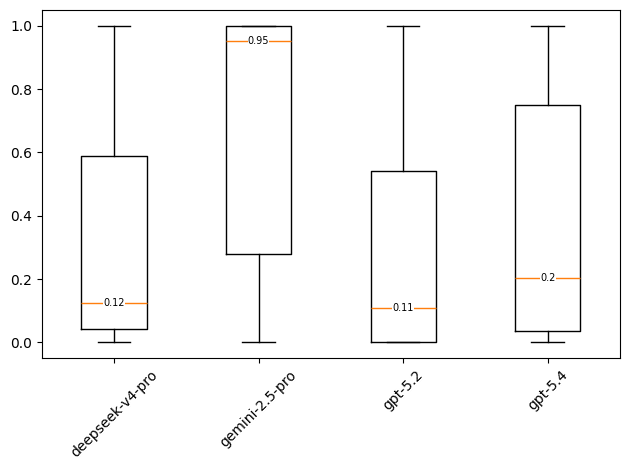

In [11]:
fig, ax = plt.subplots()
labels, data = list(zip(*((k, t['progress']) for k, t in RUNS_PER_MODEL.items())))
bp = ax.boxplot(data, tick_labels=labels)
for line in bp['medians']:
    xs, ys = line.get_xdata(), line.get_ydata()
    x, y = numpy.mean(xs), numpy.mean(ys)
    if not numpy.isnan(y):
        ax.annotate(
            f'{y:.2g}' if (y < 1.) else f'{round(y)}',
            (x, y), ha='center', va='center',
            color='black', fontsize=7, bbox={
                'boxstyle': 'square,pad=.01',
                'facecolor': 'white',
                'linewidth': .0})
ax.tick_params(axis='x', labelrotation=45)
fig.tight_layout()
plt.show()

In [12]:
pandas.DataFrame({'model': k, 'median progress': v['progress'].median()} for k, v in RUNS_PER_MODEL.items()).sort_values(by=['median progress'], ascending=False)

,model,median progress
1,gemini-2.5-pro,0.953125
3,gpt-5.4,0.203125
0,deepseek-v4-pro,0.125000
2,gpt-5.2,0.109375


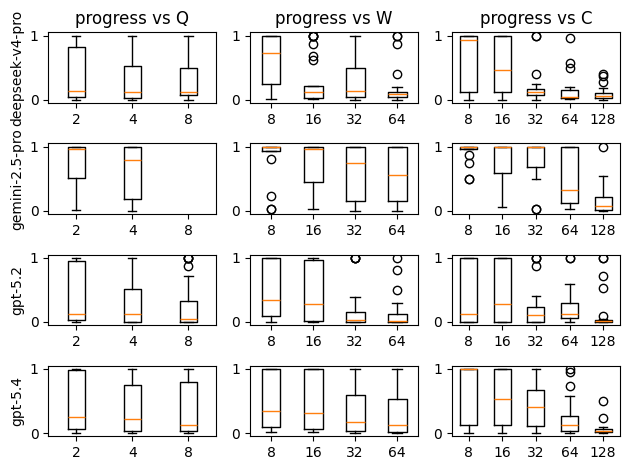

In [13]:
fig = plt.figure()
nrows, ncols = len(RUNS_PER_MODEL), 3
for i, (k, t) in enumerate(RUNS_PER_MODEL.items()):
    axQ = fig.add_subplot(nrows, ncols, i * ncols + 1)
    axQ.boxplot([t[t['Q'] == n]['progress'] for n in CFG_Qs], tick_labels=CFG_Qs)
    axW = fig.add_subplot(nrows, ncols, i * ncols + 2)
    axW.boxplot([t[t['W'] == n]['progress'] for n in CFG_Ws], tick_labels=CFG_Ws)
    axC = fig.add_subplot(nrows, ncols, i * ncols + 3)
    axC.boxplot([t[t['C'] == n]['progress'] for n in CFG_Cs], tick_labels=CFG_Cs)
    if i == 0:
        axQ.set_title('progress vs Q')
        axW.set_title('progress vs W')
        axC.set_title('progress vs C')
    axQ.set_ylabel(k)
fig.tight_layout()

## Accuracy

In [14]:
def it():
    N = list(range(0, CFG_Cs[-1] + 1))
    for k, t in RUNS_PER_MODEL.items(): 
        N_correct = pandas.Series([len(t[t['cycles'] >= i]) for i in N])
        N_total = pandas.Series([len(t[t['C'] >= i]) for i in N])
        yield pandas.DataFrame(N_correct / N_total, columns=[k])
ACC = pandas.concat(it(), axis=1)
ACC

,deepseek-v4-pro,gemini-2.5-pro,gpt-5.2,gpt-5.4
0,1.000000,1.000000,1.000000,1.000000
1,0.965517,0.972222,0.724138,0.905172
2,0.775862,0.902778,0.560345,0.801724
3,0.672414,0.888889,0.551724,0.732759
4,0.612069,0.888889,0.525862,0.663793
...,...,...,...,...
124,0.000000,0.083333,0.090909,0.000000
125,0.000000,0.083333,0.090909,0.000000
126,0.000000,0.083333,0.090909,0.000000
127,0.000000,0.083333,0.090909,0.000000


<Axes: >

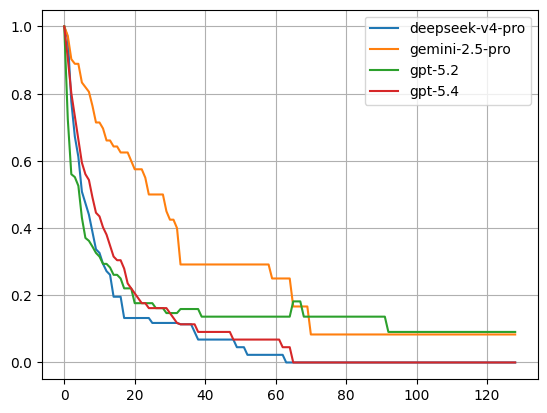

In [15]:
ACC.plot.line(grid=True)